## Milestone 2: Week 3 - Initial Model Training
- Implement U-Net.
- Train on processed data, monitor metrics.
- Visualize early predictions.

In [ ]:
# Week 3: Model Setup
import torch.nn as nn
from segmentation_models_pytorch import Unet
from segmentation_models_pytorch.losses import DiceLoss
from torchmetrics import JaccardIndex
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1, activation='sigmoid')
model.to(device)

criterion = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)
iou_metric = JaccardIndex(task='binary').to(device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1 Val: 100%|██████████| 75/75 [00:17<00:00,  4.18it/s, iou=0.758]


Epoch 1/5 - Train Loss: 1.3047, Val IoU: 0.5971


Epoch 2 Val: 100%|██████████| 75/75 [00:09<00:00,  7.91it/s, iou=0.807]


Epoch 2/5 - Train Loss: 1.2330, Val IoU: 0.5882


Epoch 3 Val: 100%|██████████| 75/75 [00:08<00:00,  8.52it/s, iou=0.825]


Epoch 3/5 - Train Loss: 1.2116, Val IoU: 0.6048


Epoch 4 Val: 100%|██████████| 75/75 [00:09<00:00,  8.17it/s, iou=0.814]


Epoch 4/5 - Train Loss: 1.2003, Val IoU: 0.6241


Epoch 5 Val: 100%|██████████| 75/75 [00:09<00:00,  7.82it/s, iou=0.751]


Epoch 5/5 - Train Loss: 1.1949, Val IoU: 0.6269


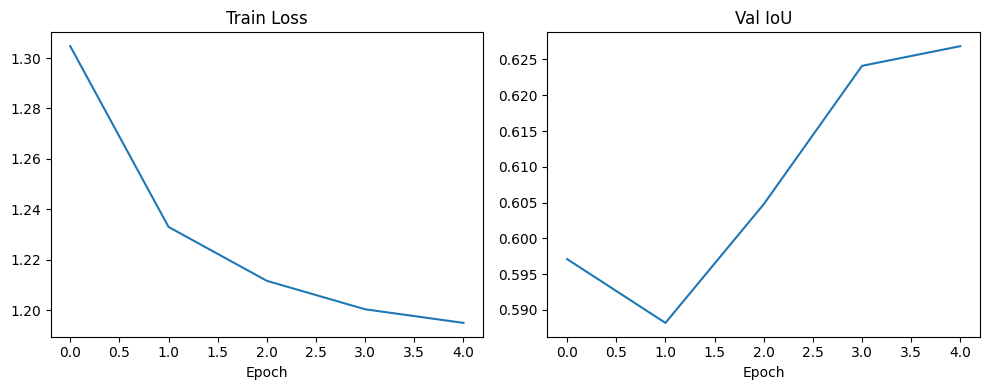

In [ ]:
# Week 3: Training Loop (5 epochs with progress)
num_epochs = 5
train_losses, val_ious = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train", total=len(train_loader))
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    iou_score = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} Val", total=len(val_loader))
    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs, masks = imgs.to(device), masks.float().to(device)
            preds = model(imgs)
            iou = iou_metric(preds.squeeze(1) > 0.5, masks.squeeze(1)).item()
            iou_score += iou
            val_pbar.set_postfix(iou=iou)
    val_ious.append(iou_score / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f}, Val IoU: {val_ious[-1]:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title('Train Loss'); plt.xlabel('Epoch')
plt.subplot(1,2,2); plt.plot(val_ious); plt.title('Val IoU'); plt.xlabel('Epoch')
plt.tight_layout()
plt.show()  # Screenshot: Training curves

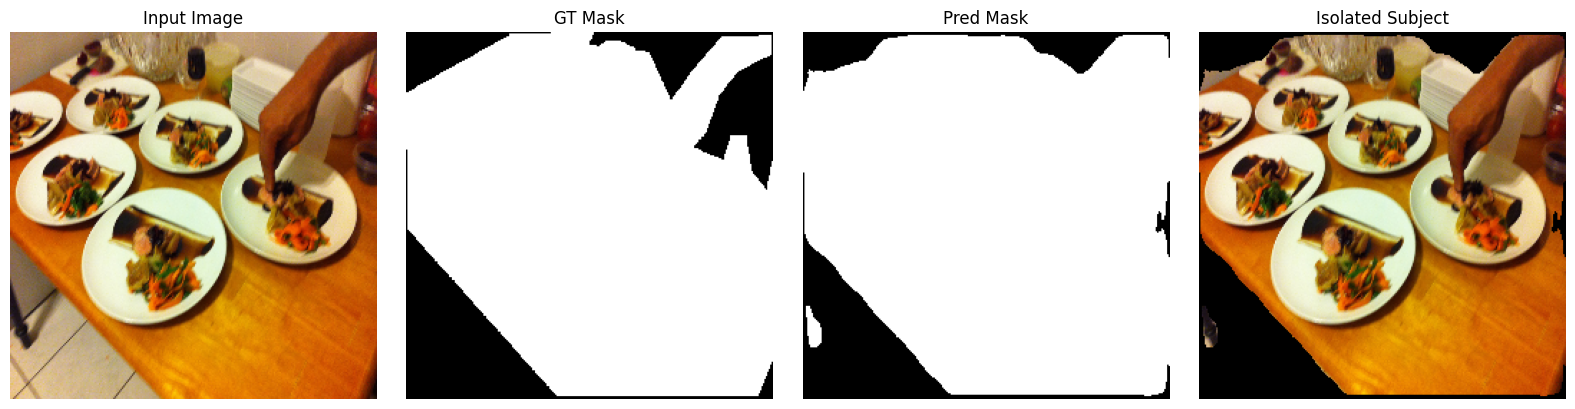

In [ ]:
# Week 3: Visualize Early Predictions
model.eval()
with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = model(imgs)
    pred_masks = (preds > 0.5).float().squeeze(1)

img_vis = denorm(imgs[0]).permute(1,2,0).cpu().numpy().clip(0,1)
gt_mask = masks[0].squeeze().cpu().numpy()
pred_mask = pred_masks[0].cpu().numpy()

isolated = img_vis.copy()
isolated[pred_mask == 0] = 0

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(img_vis); axs[0].set_title("Input Image")
axs[1].imshow(gt_mask, cmap='gray'); axs[1].set_title("GT Mask")
axs[2].imshow(pred_mask, cmap='gray'); axs[2].set_title("Pred Mask")
axs[3].imshow(isolated); axs[3].set_title("Isolated Subject")
for ax in axs: ax.axis('off')
plt.tight_layout()
plt.show()  # Screenshot: Early predictions

## Milestone 2: Week 4 - Predictions and Fine-Tuning

- Val predictions vs. GT.
- Metrics (IoU/Dice).
- Fine-tune: Add rotation aug, lower LR, retrain 3 epochs.

Val Mean IoU: 0.6269, Dice: 0.7639


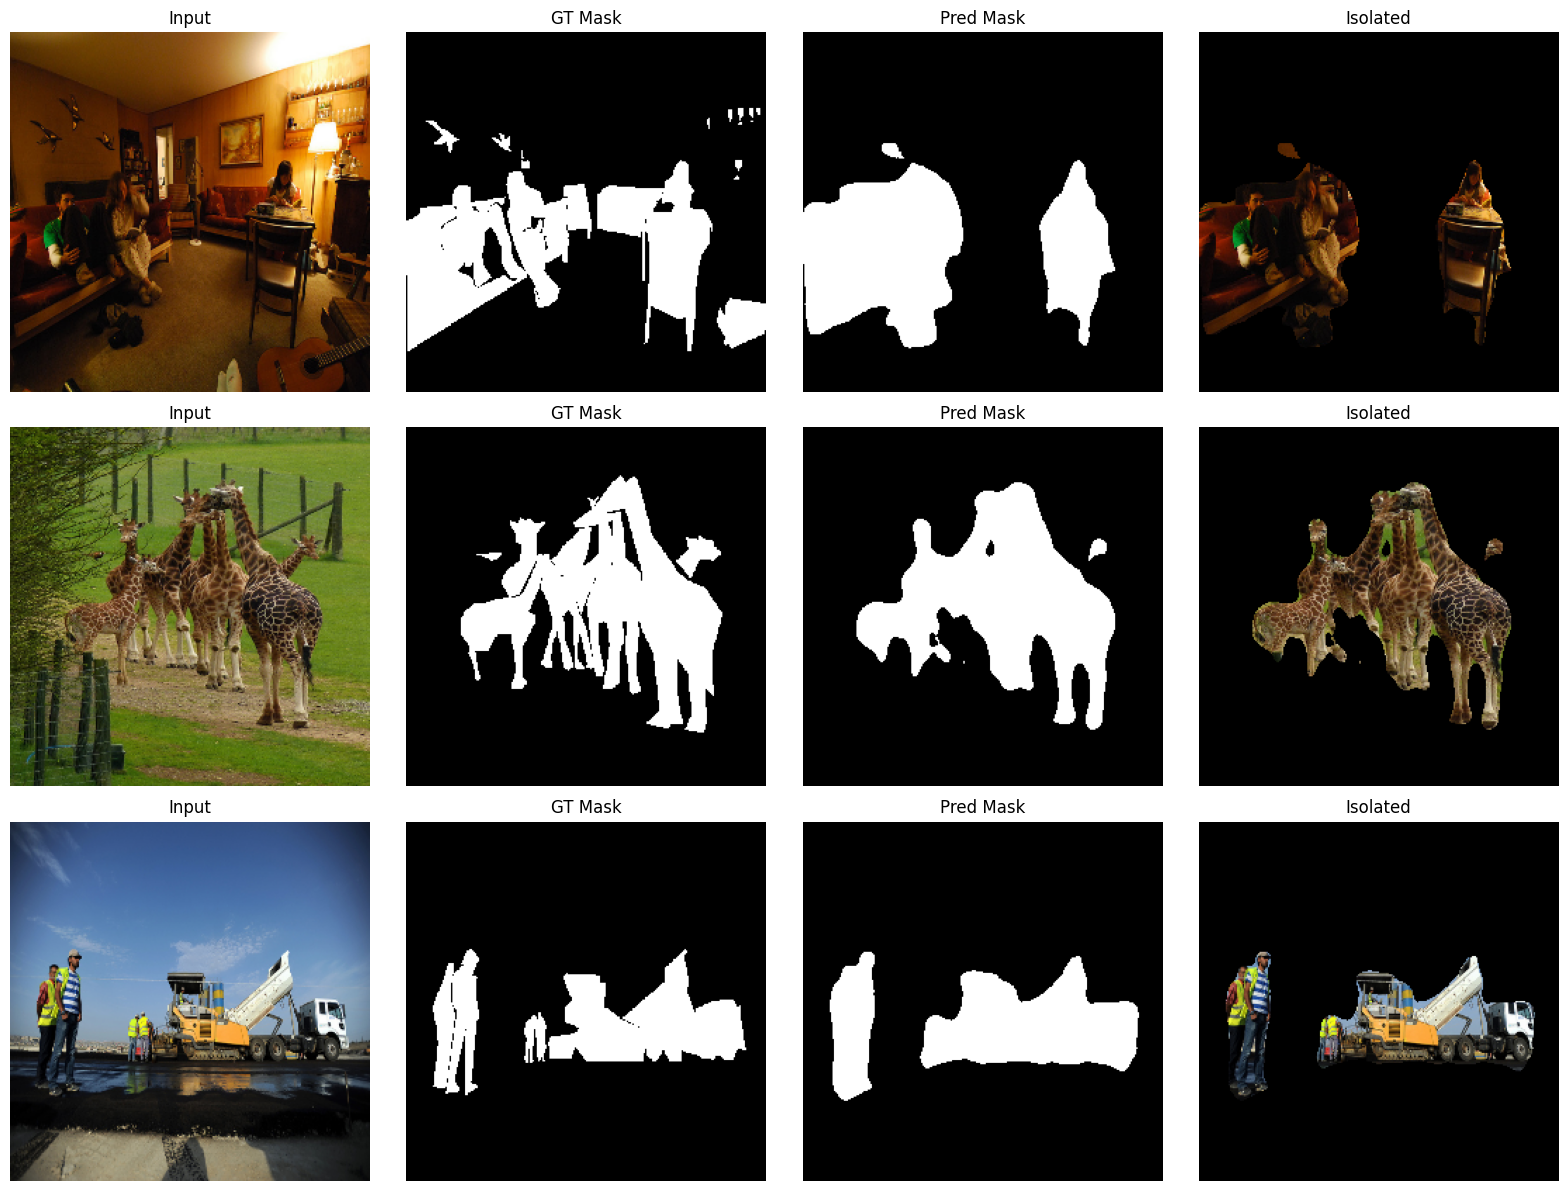

In [ ]:
# Week 4: Val Predictions & Metrics
import torchmetrics.functional as F
import random
import numpy as np



model.eval()
all_ious, all_dices = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.float().to(device)
        preds = model(imgs)
        pred_bins = (preds > 0.5).float().squeeze(1)
        all_ious.append(iou_metric(pred_bins, masks.squeeze(1)).item())
        # Calculate dice using functional API (F1-score is equivalent to Dice for binary)
        all_dices.append(F.f1_score(pred_bins.long(), masks.squeeze(1).long(), task='binary').item())

mean_iou = np.mean(all_ious)
mean_dice = np.mean(all_dices)
print(f"Val Mean IoU: {mean_iou:.4f}, Dice: {mean_dice:.4f}")

# 3 Sample Outputs
samples = [val_ds[i] for i in random.sample(range(len(val_ds)), 3)]
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for j, (img, gt) in enumerate(samples):
    img_tensor = denorm(img.unsqueeze(0).to(device)).squeeze().permute(1,2,0).cpu().numpy().clip(0,1)

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
    pred_mask = (pred > 0.5).float().squeeze().cpu().numpy()

    isolated = img_tensor.copy()
    isolated[pred_mask == 0] = 0

    axs[j,0].imshow(img_tensor); axs[j,0].set_title("Input")
    axs[j,1].imshow(gt.squeeze().numpy(), cmap='gray'); axs[j,1].set_title("GT Mask")
    axs[j,2].imshow(pred_mask, cmap='gray'); axs[j,2].set_title("Pred Mask")
    axs[j,3].imshow(isolated); axs[j,3].set_title("Isolated")
    for col in range(4): axs[j,col].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Week 4: Fine-Tuning (Add rotation, lower LR)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
train_ds = COCOSubjectDataset(coco, train_img_dir, train_ids, train_transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)

optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Retrain 3 epochs
fine_epochs = 3
for epoch in range(fine_epochs):
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Fine Epoch {epoch+1} Train", total=len(train_loader))
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())
    print(f"Fine Epoch {epoch+1} - Loss: {running_loss / len(train_loader):.4f}")



Fine Epoch 1 Train: 100%|██████████| 300/300 [01:05<00:00,  4.59it/s, loss=1.17]


Fine Epoch 1 - Loss: 1.1876


Fine Epoch 2 Train: 100%|██████████| 300/300 [01:03<00:00,  4.72it/s, loss=1.15]


Fine Epoch 2 - Loss: 1.1777


Fine Epoch 3 Train: 100%|██████████| 300/300 [01:03<00:00,  4.73it/s, loss=1.27]

Fine Epoch 3 - Loss: 1.1765
